In [48]:
%matplotlib inline
import torch
import torchvision # 使用计算机视觉库
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l


In [49]:
#加载  Fashion-MNIST图片
d2l.use_svg_display() # 使用可放缩矢量图形来计算
 # 把图片转化成向量
trans =transforms.ToTensor()
mnist_train= torchvision.datasets.FashionMNIST(root='./data', train=True, transform=trans,download=True) # 训练集 ,注意导入的是 torchvision所以需要使用导入工作
mnist_test = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=trans,download=True)  #  使用测试集

In [50]:
print(len(mnist_train ),len(mnist_test))
mnist_test[0][0].shape # RGB channel, 长 ,宽

60000 10000


torch.Size([1, 28, 28])

In [51]:
# 可视化定义
def get_fashion_mnist_labels(labels):
    text_labels = [
        't-shirt','trouser','pullover','dress','coat','sandal','shirt','sneaker','bag','ankle boot'
    ] # 分类问题： 需要设定标签的类别对象
    return [text_labels[int(i)] for i in labels] # 交叉熵损失函数的 输入需要一维数组
def show_images(imgs,num_rows,num_cols,titles = None ,scale =1.5):
    figsize =(num_cols *scale,num_rows *scale),
    _,axes = d2l.plt.subplots(num_rows,num_cols)
    axes = axes.flatten()# 唯独压缩 -> reshpae
    for i ,(ax,img) in enumerate(zip(axes,imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)


torch.Size([18, 1, 28, 28])


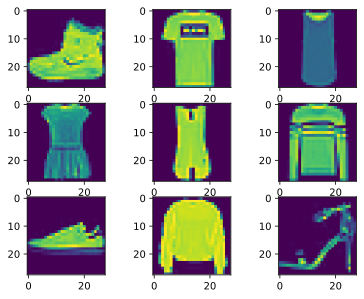

In [52]:
X, y = next(iter(data.DataLoader(mnist_train,batch_size=18))) #有了封装
print(X.shape) # 批通高宽
show_images(X.squeeze(1),3,3,titles=get_fashion_mnist_labels(y))


In [53]:
#加载进入小批量加载器
batch_size =256
def get_data_loader_workers():
    return 4 # ? 使用4个进程 并行计算
train_iter = data.DataLoader(mnist_train,batch_size,shuffle=True,num_workers=get_data_loader_workers()-2)
timer =d2l.Timer()
for X ,y in train_iter :
    continue
    #y_hat =model(X)
    #loss =criterion(y_hat,y)
    #optimizer.zero_grad()
    #optimizer.backward() ,计算梯度
    #optimizer.step()，进行迭代
f'{timer.stop():2f}sec' # benchmark

'7.199044sec'

In [54]:
def load_data_fasion_mnist(batch_size,resize = None):
    trans = [transforms.ToTensor()]
    if resize :
        trans.insert(0,transforms.Resize(resize))
    trans =transforms.Compose(trans)
    minist_train =torchvision.datasets.FashionMNIST(root='./data', train=True, transform=trans)
    minist_test = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=trans)
   # 返回训练集和测试集
    return (data.DataLoader(minist_train,batch_size),data.DataLoader(minist_test,batch_size,shuffle=True,num_workers=get_data_loader_workers()))


In [46]:
get_data_loader_workers()
get_data_loader_workers()
load_data_fasion_mnist(batch_size)


(<torch.utils.data.dataloader.DataLoader at 0x2bf57d6e030>,
 <torch.utils.data.dataloader.DataLoader at 0x2bf57be6e70>)